<a href="https://colab.research.google.com/github/427paul/Machine_Learning/blob/main/DL_4_1_CNN_%EB%AA%A8%EB%8D%B8%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN 모델링**


## **1.환경준비**

### (1) 라이브러리 Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor

# 모델 요약
from torchsummary import summary

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [4]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [5]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [6]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [7]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [8]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

#### 1) 다운로드

In [22]:
 # Download training data from open datasets.
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),   # 픽셀값을 [0,1] 사이로 정규화하고 텐서로 변환
)

# Download test data from open datasets.
test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [23]:
train_dataset, test_dataset

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

In [24]:
train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

* y(target)의 클래스

In [25]:
train_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

* 데이터 1건

In [26]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

* 데이터 이미지 확인

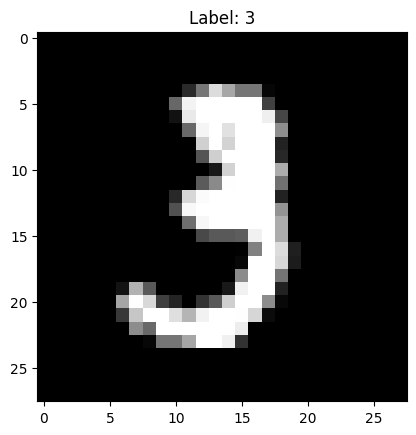

In [27]:
n = 10
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

## **2.데이터 준비**

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [28]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size = batch_size)

In [29]:
# 첫번째 배치만 로딩해서 살펴보기
for X, y in train_dataloader:
    print(f"Shape of X [batch, channels, height, width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나옵니다.
    * 스케일링 안된 데이터
    * 5000, 28, 28 : 3차원 데이터셋
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨
    * 4차원 변환 : 5000, 1, 28, 28

#### 1) 데이터 분할 : test --> val, test

In [30]:
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

In [31]:
x_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

#### 2) 스케일링

In [32]:
x_val = x_val / 255
x_test = x_test/ 255

#### 3) 3차원 데이터셋 --> 4차원 데이터셋

In [33]:
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)

print(x_val.shape, x_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## **3.모델링1**

### (1) 모델 선언
* CNN 모델의 기본구조
    * Conv2d
    * MaxPooling2d
    * Flatten
    * Linear

In [20]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),  # input = 1*28*28, output = 8*28*28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),     # input = 8*28*28, output = 8*14*14
    nn.Flatten(),
    nn.Linear(8*14*14, 64),    # 이전 레이어에서의 출력 수를 계산해서 입력으로 넣어야 함.
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# 토치 모델 요약
summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
              ReLU-2            [-1, 8, 28, 28]               0
         MaxPool2d-3            [-1, 8, 14, 14]               0
           Flatten-4                 [-1, 1568]               0
            Linear-5                   [-1, 64]         100,416
              ReLU-6                   [-1, 64]               0
            Linear-7                   [-1, 10]             650
Total params: 101,146
Trainable params: 101,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 0.39
Estimated Total Size (MB): 0.51
----------------------------------------------------------------


* 레이어의 input과 output
    1. 첫 번째 컨볼루션 레이어: nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
        * 입력: (1, 28, 28)
        * 출력: (**8**, 28, 28)
        * 이유: 패딩 1, 커널 크기 3x3, 스트라이드 1이므로 출력 크기는 입력 크기와 동일
    2. 첫 번째 맥스풀링 레이어: nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        * 입력: (8, 28, 28)
        * 출력: (8, **14, 14**)
        * 이유: 풀링 크기 2x2, 스트라이드 2이므로 각 방향의 크기가 절반으로 줄어듦

* Loss function과 Optimizer

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

### (2) 학습

In [22]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 0.3543, val loss : 0.1827
Epoch 2, train loss : 0.1207, val loss : 0.1320
Epoch 3, train loss : 0.0859, val loss : 0.1094
Epoch 4, train loss : 0.0667, val loss : 0.0916
Epoch 5, train loss : 0.0535, val loss : 0.0804
Epoch 6, train loss : 0.0438, val loss : 0.0762
Epoch 7, train loss : 0.0360, val loss : 0.0763
Epoch 8, train loss : 0.0295, val loss : 0.0780
Epoch 9, train loss : 0.0240, val loss : 0.0829
Epoch 10, train loss : 0.0190, val loss : 0.0903


* 학습 곡선

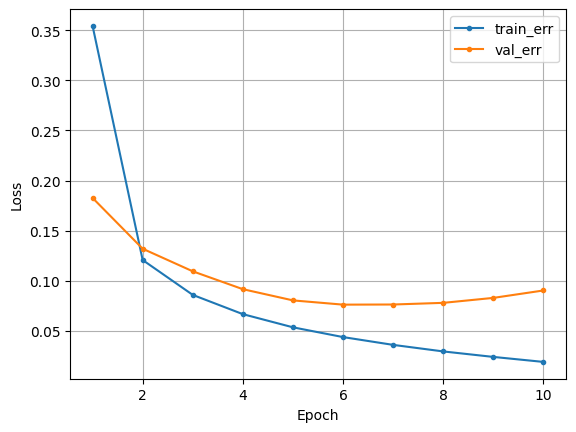

In [23]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [24]:
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred[:5]

tensor([[-14.0632, -15.4280,  -3.3648,  14.8098,  -6.2564,   1.1797, -19.6477,
         -13.8619,  -1.0701,  -3.5346],
        [ -6.0130, -18.6897,  -4.8232,  -2.8450,  -2.1153,  -9.0838, -14.6013,
          -6.1826,   0.9843,   9.8190],
        [-11.6639, -15.7592, -10.4831,  -2.1695,  -0.1027,  -8.9636, -15.4332,
          -3.1970,  -1.5972,  14.4069],
        [-13.7411, -13.0570,   1.9682,  -4.4771, -11.3114, -11.3050, -21.5568,
          -9.9947,  14.2449,  -5.0729],
        [ -6.0975,  -4.2747,  -7.0943, -11.6920,  16.3164, -13.8889, -10.1533,
          -3.0528,  -5.1509,  -0.9558]], device='cuda:0')

* 예측결과를 각 클래스별 확률값으로 변환 : nn.functional.softmax()
* 가장 확률이 높은 클래스 찾기 : np.argmax()

In [25]:
pred = nn.functional.softmax(pred, dim=1) # 예측 결과를 softmax를 이용하여 확률로 변환
pred = np.argmax(pred.cpu().numpy(), axis = 1) # argmax로 확률 중 가장 큰 확률 선택
# gpu 연산 결과를 numpy 변환을 위해 cpu 변환을 거침
pred

array([3, 9, 9, ..., 4, 5, 6])

* confusion matrix

In [26]:
cm = confusion_matrix(y_test.numpy(), pred)
cm

array([[516,   1,   0,   1,   0,   1,   1,   0,   0,   0],
       [  0, 563,   0,   0,   0,   0,   1,   0,   0,   0],
       [  0,   2, 499,   0,   0,   0,   0,   1,   0,   0],
       [  1,   0,   1, 506,   0,   2,   0,   0,   0,   0],
       [  0,   0,   1,   0, 481,   0,   0,   0,   0,   0],
       [  1,   0,   0,   1,   0, 433,   1,   0,   0,   0],
       [  1,   0,   1,   0,   0,   2, 492,   0,   0,   0],
       [  1,   1,   5,   1,   0,   0,   0, 506,   0,   2],
       [  0,   0,   2,   0,   1,   2,   0,   1, 478,   1],
       [  0,   0,   0,   0,   1,   3,   0,   3,   3, 479]])

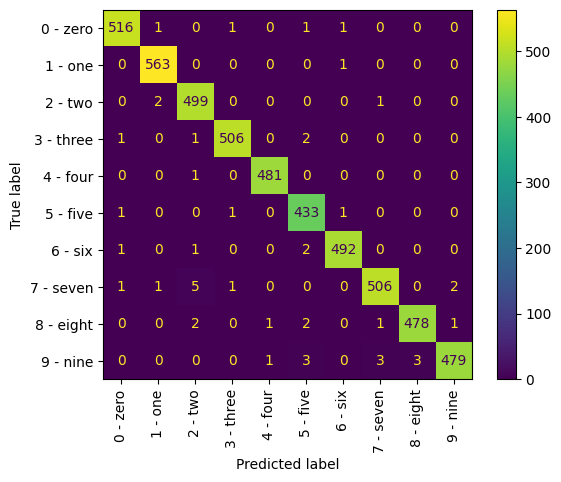

In [27]:
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

* classification_report

In [28]:
print(accuracy_score(y_test.numpy(), pred))
print('-'*100)
print(classification_report(y_test.numpy(), pred))

0.9906
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       520
           1       0.99      1.00      1.00       564
           2       0.98      0.99      0.99       502
           3       0.99      0.99      0.99       510
           4       1.00      1.00      1.00       482
           5       0.98      0.99      0.99       436
           6       0.99      0.99      0.99       496
           7       0.99      0.98      0.99       516
           8       0.99      0.99      0.99       485
           9       0.99      0.98      0.99       489

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



## **4.모델링2 : 실습**

* 아래 그림처럼 모델을 구성하시오.


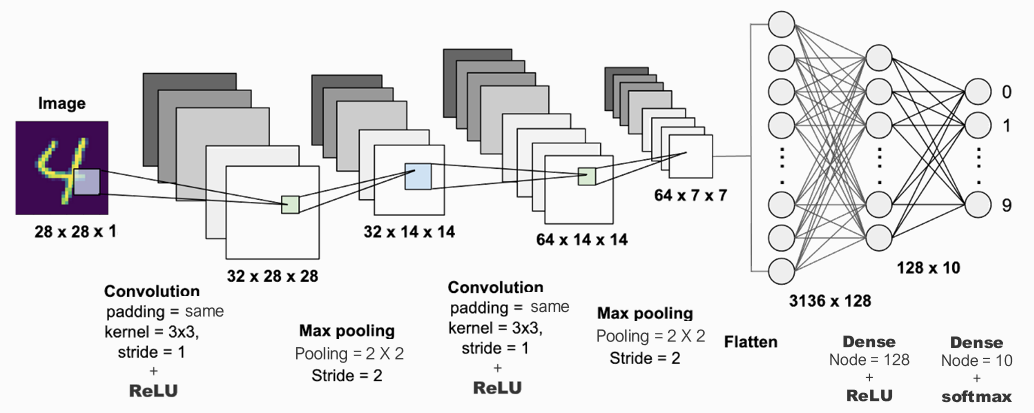

### (1) 모델 선언

In [34]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),
    nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),
    nn.Flatten(),
    nn.Linear(64*7*7, 128),
    nn.ReLU(),
    nn.Linear(128, n_class)

).to(device)

# 모델 요약
summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
           Flatten-7                 [-1, 3136]               0
            Linear-8                  [-1, 128]         401,536
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.67
Params size (MB): 1.61
Estimated T

* Loss function과 Optimizer

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

### (2) 학습

In [36]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 0.1802, val loss : 0.1522
Epoch 2, train loss : 0.0522, val loss : 0.0600
Epoch 3, train loss : 0.0338, val loss : 0.0480
Epoch 4, train loss : 0.0244, val loss : 0.0526
Epoch 5, train loss : 0.0177, val loss : 0.0549
Epoch 6, train loss : 0.0147, val loss : 0.0668
Epoch 7, train loss : 0.0118, val loss : 0.0560
Epoch 8, train loss : 0.0087, val loss : 0.0680
Epoch 9, train loss : 0.0083, val loss : 0.0520
Epoch 10, train loss : 0.0074, val loss : 0.0623


* 학습 곡선

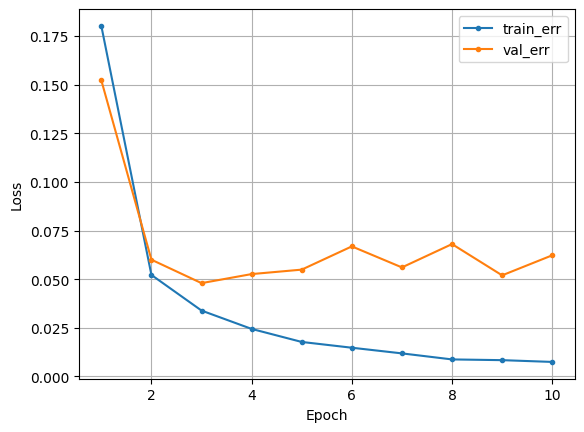

In [37]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [38]:
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred[:5]

tensor([[-19.3384,  -4.1871,  -5.5227,  17.1408, -14.2956,  -4.0512, -17.2144,
          -4.2080,  -8.8564,  -5.3927],
        [-12.1446, -22.5782, -11.2720,  -6.5903,  -4.1878, -12.2917, -26.0018,
          -7.3835,   3.0609,  19.4820],
        [ -9.6138, -19.1070, -14.9265,  -3.6957,  -6.8123, -12.7780, -24.0716,
          -4.7814,  -0.7868,  19.5679],
        [-16.5220, -11.1293,  -1.5021,  -1.0041, -16.3155,  -7.6425, -19.5424,
          -7.6308,  20.3230,  -8.0527],
        [-14.1671,  -8.2640, -10.9579, -20.7323,  24.6886,  -9.4415, -17.0968,
          -9.4637, -11.6942,   1.2388]], device='cuda:0')

* 예측결과를 각 클래스별 확률값으로 변환 : nn.functional.softmax()
* 가장 확률이 높은 클래스 찾기 : np.argmax()

In [39]:
pred = nn.functional.softmax(pred, dim=1) # 예측 결과를 softmax를 이용하여 확률로 변환
pred = np.argmax(pred.cpu().numpy(), axis = 1) # argmax로 확률 중 가장 큰 확률 선택
# gpu 연산 결과를 numpy 변환을 위해 cpu 변환을 거침
pred

array([3, 9, 9, ..., 4, 5, 6])

* confusion matrix

In [40]:
cm = confusion_matrix(y_test.numpy(), pred)
cm

array([[518,   0,   0,   0,   0,   0,   0,   0,   1,   1],
       [  0, 562,   0,   0,   0,   1,   1,   0,   0,   0],
       [  0,   0, 502,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   2, 508,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 479,   0,   0,   0,   0,   3],
       [  0,   0,   0,   2,   0, 434,   0,   0,   0,   0],
       [  1,   0,   1,   0,   0,   1, 493,   0,   0,   0],
       [  1,   0,   4,   0,   0,   0,   0, 511,   0,   0],
       [  0,   0,   1,   1,   0,   1,   0,   0, 481,   1],
       [  0,   0,   0,   0,   0,   2,   0,   1,   0, 486]])

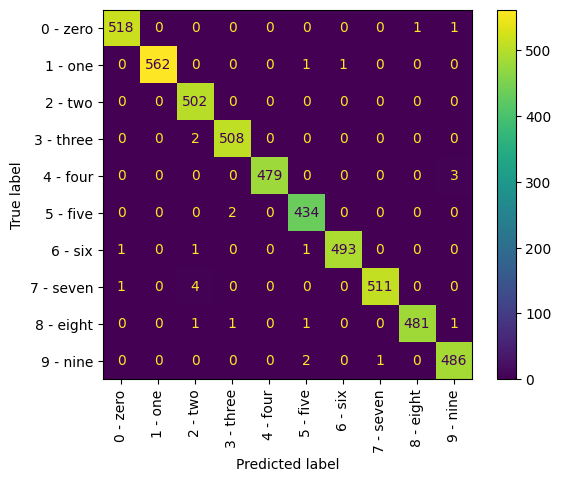

In [41]:
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

* classification_report

In [42]:
print(accuracy_score(y_test.numpy(), pred))
print('-'*100)
print(classification_report(y_test.numpy(), pred))

0.9948
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       520
           1       1.00      1.00      1.00       564
           2       0.98      1.00      0.99       502
           3       0.99      1.00      1.00       510
           4       1.00      0.99      1.00       482
           5       0.99      1.00      0.99       436
           6       1.00      0.99      1.00       496
           7       1.00      0.99      0.99       516
           8       1.00      0.99      0.99       485
           9       0.99      0.99      0.99       489

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



## **5.틀린그림 찾아보기**
* 모델링의 결과에서 틀린 그림을 살펴 봅시다.
* 아래코드는 이해하기보다는 그냥 사용하기 바랍니다.

In [43]:
import random as rd

In [44]:
idx = (y_test.numpy() != pred)
x_test_wr = x_test[idx]
y_test_wr = y_test[idx]
pred_wr = pred[idx]

x_test_wr = x_test_wr.reshape(-1,28,28)
print(x_test_wr.shape)

torch.Size([26, 28, 28])


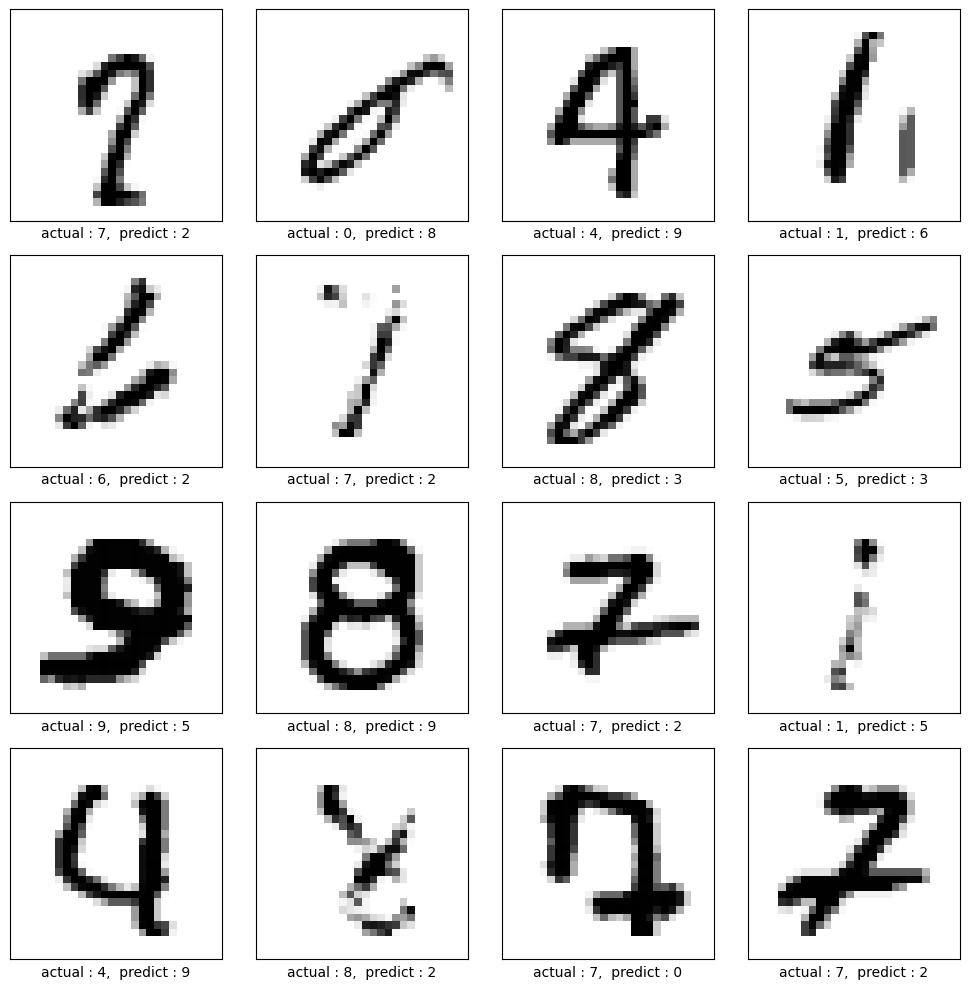

In [45]:
idx = rd.sample(range(x_test_wr.shape[0]),16)
x_temp = x_test_wr[idx]
y_temp = y_test_wr[idx]
p_temp = pred_wr[idx]

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_temp[i], cmap=plt.cm.binary)
    plt.xlabel(f'actual : {y_temp[i]},  predict : {p_temp[i]}')
plt.tight_layout()
plt.show()

## **6.진짜 손글씨로 예측해 봅시다.**

### (1) 데이터 준비

* 이미지 처리를 위한 라이브러리와 함수 불러오기

In [46]:
import cv2
from google.colab.patches import cv2_imshow

* 그림판에서 그린 손글씨를 업로드 합니다.

In [48]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving 02.png to 02 (1).png


* 업로드 후 왼쪽 파일 창 확인

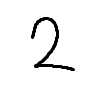

(100, 100)


In [49]:
# 그림 확인
img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)
cv2_imshow(img)
print(img.shape)

* 이미지 크기 조절하기

In [50]:
# 1. 크기 조절하기
img = cv2.resize(255-img, (28, 28))
print(img.shape)
cv2_imshow(img)

(28, 28)


In [51]:
# 2. (1, 1, 28, 28) 로 변환
new_data = img.reshape(1,1,28,28)

# 3. 스케일링
new_data = new_data / 255

# 4. 텐서로 변환
new_data = torch.tensor(new_data, dtype=torch.float32)
new_data

tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

### (2) 예측하기

In [52]:
model.eval()
with torch.no_grad():
    new_data = new_data.to(device)
    pred = model(new_data)
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)

pred

array([2])

### (3) 함수로 만들기

In [53]:
def predict_number(model, device ):
    uploaded = files.upload()
    img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)

    # 1. 크기 조절하기
    img = cv2.resize(255-img, (28, 28))
    cv2_imshow(img)

    print('입력데이터')
    print(img.shape)
    print('-'*50)

    # 2. (1, 1, 28, 28) 로 변환
    new_data = img.reshape(1,1,28,28)

    # 3. 스케일링
    new_data = new_data / 255

    # 4. 텐서로 변환
    new_data = torch.tensor(new_data, dtype=torch.float32)

    # 5. 예측
    model.eval()
    with torch.no_grad():
        new_data = new_data.to(device)
        pred = model(new_data)
        pred = nn.functional.softmax(pred, dim=1)
        pred = np.argmax(pred.cpu().numpy(), axis = 1)

    return pred[0]

In [55]:
predict_number(model, device)

Saving 02.png to 02 (2).png


입력데이터
(28, 28)
--------------------------------------------------


np.int64(2)